In [1]:
source("utils.r")
source("preparar_dataframes.r")
library(starvars)
library(zoo)

[1] "Se creó df_trimestral_crudo"
[1] "Se creó df_Arg"
[1] "Se creó df_ERPT_Arg1"
[1] "Se creó df_ERPT_Arg"


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




#### Pruebas realizadas
| endog | iteraciones | convergence_method | n_combi | n_regimes | round_convergencia | coefs |
| ----- | ----------- | ------------------ | ------- | --------- | ------------------ | ----- |
| c("Psoja_USA", "E","ipc","pbird") | 150 | NLS | 2 | 2 | 95 | [] |
| c("Psoja_USA", "E","ipc","pbird") | 150 | ML | 2 | 2 | 150 | [] |
| c("Psoja_USA", "E","ipc","pbird") | 200 | ML | 2 | 3 | 200 | [] |
| c("Psoja_USA", "E","ipc","pbird") | 300 | ML | 2 | 3 | 300 | [] |
| c("Psoja_USA", "E","ipc","pbird") | 500 | ML | 2 | 3 | 500 | [] |

## Configuración

In [2]:
df                  <- df_ERPT_Arg         # dataframe sobre el que trabajar
regression_var_lag  <- 2                   # lag order for endogenous variables (p)
transition_var_lag  <- 1                   # lag for the transition variable (used to select st)
trans_col           <- c('ipc')            # Variable de transición
n_regimes           <- 2                   # number of regimes (must be >= 2)
# NULL = use all numeric columns; or e.g. c("ipc","E","pbird")
endog_vars         <- c("Pmaíz_USA", "E","ipc","pbird")
exog_vars           <- c()                 # exogenous variable names (character vector, can be empty)
include_const       <- TRUE                # include intercept in the model
ncores              <- 4                   # number of cores for parallel computation
n_iter              <- 500                   # number of NLS iterations
n_combi             <- 5                   # number of gamma/c combinations tried in startingVLSTAR (subir a 3 para corridas finales)
convergence_method  <- 'ML'                # NLS (non-linear least squares) o ML (maximum likelihood)
single_cgamma       <- FALSE               # TRUE = one common gamma/c across equations
df

,año,trimestre,ipc,E,Ebc,pbird,impp_usa,Psoja_USA,Pmaíz_USA,Ptrigo_USA,TOTfmi
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,1950,2ºTr,0.0710476068,0.000000000000,0.000000000000,-0.016444578,NA,0.209470249,0.123481057,0.058301271,NA
3,1950,3ºTr,0.0485426448,0.182256883601,0.182256883601,0.037674929,NA,-0.048727588,0.087011377,-0.046365921,NA
4,1950,4ºTr,0.0686389229,0.259639217954,0.259639217954,-0.012975314,NA,-0.045706880,-0.030554668,-0.006802747,NA
5,1951,1ºTr,0.0228032118,0.001405321461,0.001405321461,0.027127918,NA,0.222317901,0.123336402,0.091268514,NA
6,1951,2ºTr,0.1578569708,0.004855917800,0.004855917800,0.012084985,NA,0.016384856,0.029108084,-0.014117882,NA
7,1951,3ºTr,0.1057701537,0.006299696673,0.006299696673,-0.006213927,NA,-0.123214880,0.010193768,-0.025601398,NA
8,1951,4ºTr,0.0767790005,0.013470343239,0.013470343239,-0.004386448,NA,0.007326040,0.000000000,0.053640618,NA
9,1952,1ºTr,0.1087066196,-0.016188205390,-0.016188205390,0.002419679,NA,0.012092046,0.010090903,0.010695289,NA
10,1952,2ºTr,0.0994670088,-0.011716739820,-0.011716739820,-0.032405660,NA,0.022579688,0.025769513,-0.032435276,NA


## Setup datos

In [3]:
raw <- df

# Keep only numeric columns (drop año, trimestre, etc.)
numeric_cols <- names(raw)[sapply(raw, is.numeric)]
numeric_cols <- numeric_cols[numeric_cols != "año"]
 
# Select endogenous variables
if (is.null(endog_vars)) {
  endog_vars <- numeric_cols
} else {
  endog_vars <- intersect(endog_vars, numeric_cols)
}
 
# Build the main numeric matrix (rows = observations)
df_num <- raw[, endog_vars, drop = FALSE]
 
# Drop rows where ALL endogenous variables are NA
keep      <- rowSums(is.na(df_num)) < ncol(df_num)
df_num    <- df_num[keep, ]
raw_clean <- raw[keep, ]          # keep raw in sync for date reconstruction
 
# For columns with isolated NAs, replace with column mean (simple imputation)
for (col in names(df_num)) {
  if (any(is.na(df_num[[col]]))) {
    col_mean <- mean(df_num[[col]], na.rm = TRUE)
    df_num[[col]][is.na(df_num[[col]])] <- col_mean
    message("Note: NA values in '", col, "' replaced with column mean.\nTODO: VER SI ESTO ES UN COMPORTAMIENTO ACEPTABLE O METE RUIDO!!")
  }
}
 

### Build date index

In [4]:
# Detect the year column (handles "anno", "año", "year", etc.)
year_col <- names(raw_clean)[grep("^a", names(raw_clean), ignore.case = TRUE)[1]]
tq_col   <- names(raw_clean)[grep("trimestre", names(raw_clean), ignore.case = TRUE)[1]]
 
# Map quarter number to first month of each quarter
q2m <- c("1" = "01", "2" = "04", "3" = "07", "4" = "10")
 
# Extract the leading digit from strings like "1oTr", "2oTr", "1ºTr", etc.
tq_number    <- substr(as.character(raw_clean[[tq_col]]), 1, 1)
months       <- q2m[tq_number]
date_strings <- paste0(raw_clean[[year_col]], "-", months, "-01")
all_dates    <- as.Date(date_strings)             # length == T_full

```txt
 =============================================================================
 2. BUILD y AND st FOLLOWING THE starvars CONVENTION

    The package example does:
      y  <- Realized[-1, 1:10]          # drop first row, use as levels
      y  <- y[-nrow(y), ]               # drop last row
      st <- Realized[-nrow(Realized), 1]# drop last row of full series
      st <- st[-length(st)]             # drop last element

    In plain terms:
      - y  contains rows [2, T-1]  of the data matrix
      - st contains rows [1, T-2]  of the chosen transition variable
    This means st_t is dated one step before y_t (i.e., st uses lag = 1).
    Increase the initial offset to use a longer lag for the transition variable.
 =============================================================================
 ```

In [5]:
T_full <- nrow(df_num)
 
# Validate transition variable column
if (!trans_col %in% names(df_num)) {
  stop("trans_col '", trans_col, "' not found in the data. ",
       "Available columns: ", paste(names(df_num), collapse = ", "))
}
 
offset <- transition_var_lag
 
# y: rows (offset+1) through (T_full - 1)
y <- as.matrix(df_num[(offset + 1):(T_full - 1), , drop = FALSE])
rownames(y) <- NULL
 
# st: plain numeric values, rows 1 through (T_full - 1 - offset)
st_values <- df_num[[trans_col]][1:(T_full - 1 - offset)]
st_dates  <- all_dates[1:(T_full - 1 - offset)]
 
# Wrap in zoo so plot.VLSTAR can extract a Date index via index()
st <- zoo(st_values, order.by = format(st_dates, "%m/%d/%Y"))

In [6]:
# Cap los valores extremos de la variable de transición a un percentil razonable,
# sin alterar el resto de la distribución
# cap <- quantile(st_values, 0.95, na.rm = TRUE)
# st_values_capped <- pmin(st_values, cap)
cap_low  <- quantile(st_values, 0.05, na.rm = TRUE)
cap_high <- quantile(st_values, 0.90, na.rm = TRUE)  # más agresivo que el 0.95 anterior
st_values_capped <- pmin(pmax(st_values, cap_low), cap_high)
st <- zoo(st_values_capped, order.by = st_dates)

In [7]:
cat("==============================================================\n")
cat("Dataset summary\n")
cat("  Full observations      :", T_full, "\n")
cat("  Endogenous variables   :", ncol(y), "->", paste(endog_vars, collapse = ", "), "\n")
cat("  y dimensions           :", nrow(y), "rows x", ncol(y), "cols\n")
cat("  st length              :", length(st), "\n")
cat("  Regression lag (p)     :", regression_var_lag, "\n")
cat("  Transition variable    :", trans_col, "\n")
cat("  Transition var lag     :", transition_var_lag, "\n")
cat("  Number of regimes      :", n_regimes, "\n")
cat("  Include constant       :", include_const, "\n")
cat("==============================================================\n\n")

Dataset summary
  Full observations      : 295 
  Endogenous variables   : 4 -> Pmaíz_USA, E, ipc, pbird 
  y dimensions           : 293 rows x 4 cols
  st length              : 293 
  Regression lag (p)     : 2 
  Transition variable    : ipc 
  Transition var lag     : 1 
  Number of regimes      : 2 
  Include constant       : TRUE 



Resumen de st:
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-0.002687  0.024830  0.060550  0.096124  0.134918  0.287291 
Observaciones con |st| > 1 (posibles outliers extremos):
Data:
numeric(0)

Index:
Date of length 0


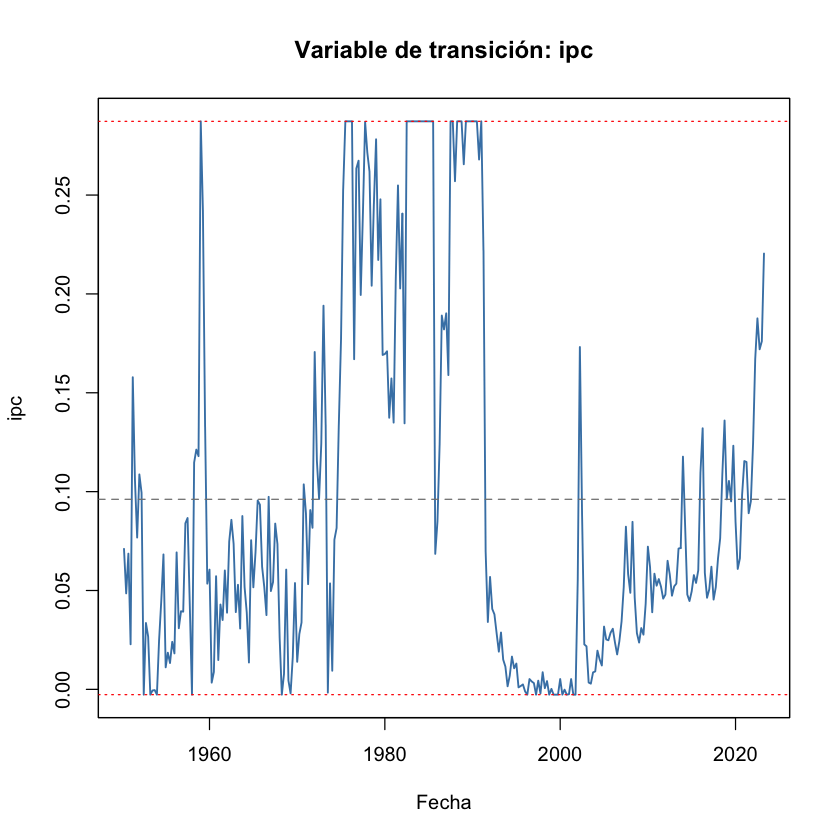

In [8]:
st_plot <- zoo(as.numeric(st), order.by = st_dates)

plot(st_plot, type = "l", col = "steelblue", lwd = 1.5,
     main = paste("Variable de transición:", trans_col),
     xlab = "Fecha", ylab = trans_col)
abline(h = mean(st_plot), col = "grey50", lty = 2)
abline(h = quantile(st_plot, c(0.01, 0.99)), col = "red", lty = 3)

cat("Resumen de st:\n")
print(summary(as.numeric(st_plot)))
cat("Observaciones con |st| > 1 (posibles outliers extremos):\n")
print(st_plot[abs(as.numeric(st_plot)) > 1])

## Modelar

### Probar linearidad

```txt
# =============================================================================
# 3b. LINEARITY TEST (run this before estimating -- if linearity is not
#     rejected the VLSTAR is unidentified and coefficients will be empty)
#
#     VLSTARjoint() tests H0: gamma = 0 for all equations (i.e. the model
#     is linear).  You need to reject H0 to justify estimating a VLSTAR.
# =============================================================================
```

In [9]:
cat(">>> Testing linearity via VLSTARjoint ...\n")
linearity_test <- VLSTARjoint(y, st = st)
print(linearity_test)
 
cat("\n")
cat("If p-value >> 0.05: linearity NOT rejected -> VLSTAR may not be appropriate.\n")
cat("If p-value <  0.05: nonlinearity detected  -> proceed with VLSTAR.\n\n")

>>> Testing linearity via VLSTARjoint ...

Joint linearity test (Third-order Taylor expansion)
 LM = 138 ; p-value = 0.00000000000000000000547 
 Critical value for alpha = 30.2 

If p-value >> 0.05: linearity NOT rejected -> VLSTAR may not be appropriate.
If p-value <  0.05: nonlinearity detected  -> proceed with VLSTAR.



### Generar valores iniciales

In [10]:
stvalues <- startingVLSTAR(
  y,
  p            = regression_var_lag,
  n.combi      = n_combi,
  singlecgamma = single_cgamma,
  st           = st,
  ncores       = ncores,
  m = n_regimes
)

Searching optimal c and gamma among 25 combinations




  |======================================================================| 100%


### Estimatar VLstar

In [11]:
#fit.VLSTAR <- readRDS("fit_vlstar.rds")

In [12]:
sink("output.txt", split = TRUE)
fit.VLSTAR <- VLSTAR(
  y,
  p            = regression_var_lag,
  singlecgamma = single_cgamma,
  starting     = stvalues,
  n.iter       = n_iter,
  st           = st,
  method       = convergence_method,
  ncores       = ncores,
  m = n_regimes
)
sink()

Maximum likelihood estimation


iteration 1 complete




Log-likelihood: 9128.934 


iteration 2 complete




Log-likelihood: -1063.195 


iteration 3 complete




...

iteration 499 complete




Log-likelihood: 5571.792 


iteration 500 complete




Log-likelihood: -1063.285 


Converged after 500 iterations




In [13]:
# Save the fitted model so you can reload it without re-running
saveRDS(fit.VLSTAR, "fit_vlstar_claude.rds")
cat(">>> Fit saved to fit_vlstar_claude.rds\n")

>>> Fit saved to fit_vlstar_claude.rds


## Resultados - no acumulado

In [14]:
system("spd-say 'Model estimation complete'")

Warning message in system("spd-say 'Model estimation complete'"):
“error in running command”


In [15]:
iterations <- as.numeric(gsub(".*after ([0-9]+) iterations.*", "\\1", grep("Converged after", readLines("output.txt"), value = TRUE)))
cat(">>> ITERATIONS\n")
cat(iterations)
cat("\n>>> Coefficients\n")
coefs <- coef(fit.VLSTAR)
summary(fit.VLSTAR)

Warning message in readLines("output.txt"):
“line 33 appears to contain an embedded nul”


>>> ITERATIONS

>>> Coefficients


Model VLSTAR with 2 regimes
Full sample size: 291 
Number of estimated parameters: 88 	Multivariate log-likelihood: -1063.285 

Equation y1 

Coefficients regime 1 
          const Pmaíz_USA.lag-1         E.lag-1       ipc.lag-1     pbird.lag-1 
       1.6e-05         6.6e-08         2.8e-06         2.9e-06         5.9e-08  
Pmaíz_USA.lag-2         E.lag-2       ipc.lag-2     pbird.lag-2 
       6.6e-08         2.8e-06         2.8e-06         6.0e-08  

Coefficients regime 2 
          const Pmaíz_USA.lag-1         E.lag-1       ipc.lag-1     pbird.lag-1 
       2.0e-05         7.8e-08         4.0e-06         4.1e-06         5.8e-08  
Pmaíz_USA.lag-2         E.lag-2       ipc.lag-2     pbird.lag-2 
       7.3e-08         4.0e-06         3.9e-06         6.0e-08  

Gamma: 7.8318 	c: 0.2873 
AIC: -1005.6 	BIC: -939.48 	LL: 520.8 

Equation y2 

Coefficients regime 1 
          const Pmaíz_USA.lag-1         E.lag-1       ipc.lag-1     pbird.lag-1 
       2.4e-04         9.8e-07         4.2


>>> print(fit.VLSTAR)

VLSTAR model Estimation through ML 
Coefficients:
$`Regime 1`
[1] Pmaíz_USA E         ipc       pbird    
<0 rows> (or 0-length row.names)

$`Regime 2`
[1] Pmaíz_USA E         ipc       pbird    
<0 rows> (or 0-length row.names)


Smoothing parameter: gamma =  7.832 11.504  9.072 13.507 

Threshold
Value:  0.287291  0.287291 -0.002687  0.287291 

>>> summary(fit.VLSTAR)


Model VLSTAR with 2 regimes
Full sample size: 291 
Number of estimated parameters: 88 	Multivariate log-likelihood: -1063.285 

Equation y1 

Coefficients regime 1 
          const Pmaíz_USA.lag-1         E.lag-1       ipc.lag-1     pbird.lag-1 
       1.6e-05         6.6e-08         2.8e-06         2.9e-06         5.9e-08  
Pmaíz_USA.lag-2         E.lag-2       ipc.lag-2     pbird.lag-2 
       6.6e-08         2.8e-06         2.8e-06         6.0e-08  

Coefficients regime 2 
          const Pmaíz_USA.lag-1         E.lag-1       ipc.lag-1     pbird.lag-1 
       2.0e-05         7.8e-08         4.0e-06         4.1e-06         5.8e-08  
Pmaíz_USA.lag-2         E.lag-2       ipc.lag-2     pbird.lag-2 
       7.3e-08         4.0e-06         3.9e-06         6.0e-08  

Gamma: 7.8318 	c: 0.2873 
AIC: -1005.6 	BIC: -939.48 	LL: 520.8 

Equation y2 

Coefficients regime 1 
          const Pmaíz_USA.lag-1         E.lag-1       ipc.lag-1     pbird.lag-1 
       2.4e-04         9.8e-07         4.2


>>> predict (1-step ahead)
$Pmaíz_USA
              fcst   lower 95%  upper 95%
[1,] 0.00002708835 -0.01012075 0.01017493

$E
             fcst   lower 95%  upper 95%
[1,] 0.0003811238 -0.02618439 0.02694664

$ipc
             fcst   lower 95%  upper 95%
[1,] 0.0002234627 -0.02330504 0.02375196

$pbird
                fcst    lower 95%   upper 95%
[1,] -0.000003822552 -0.002836349 0.002828704


>>> Log-likelihood (univariate)
'log Lik.' 520.7999, 240.7551, 276.0829, 892.1426 (df=564)

>>> Coefficients
NULL

>>> plot(fit.VLSTAR)


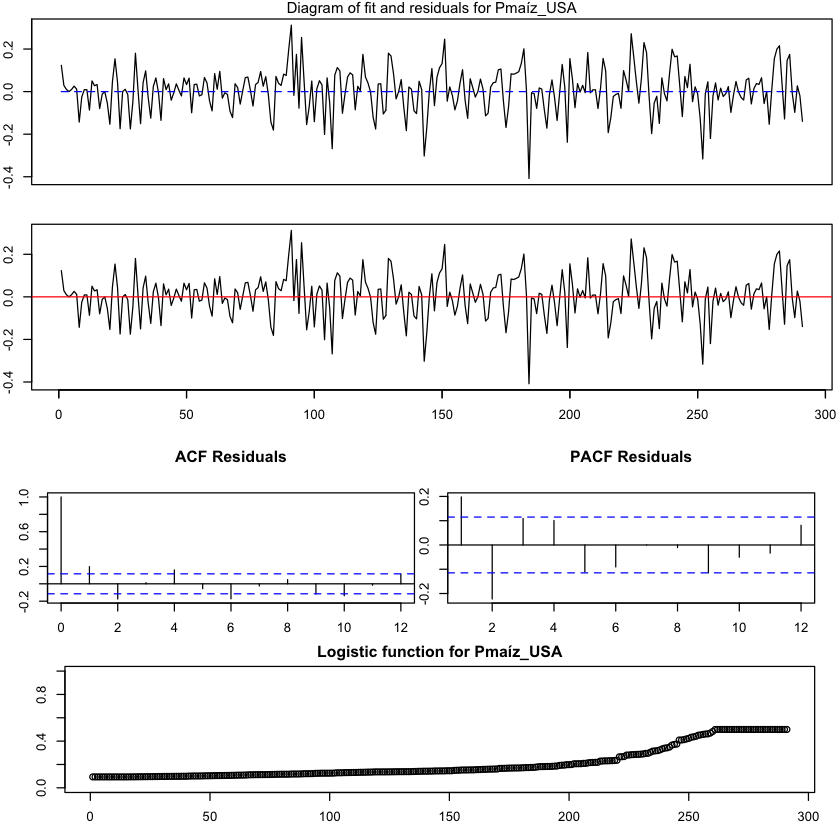

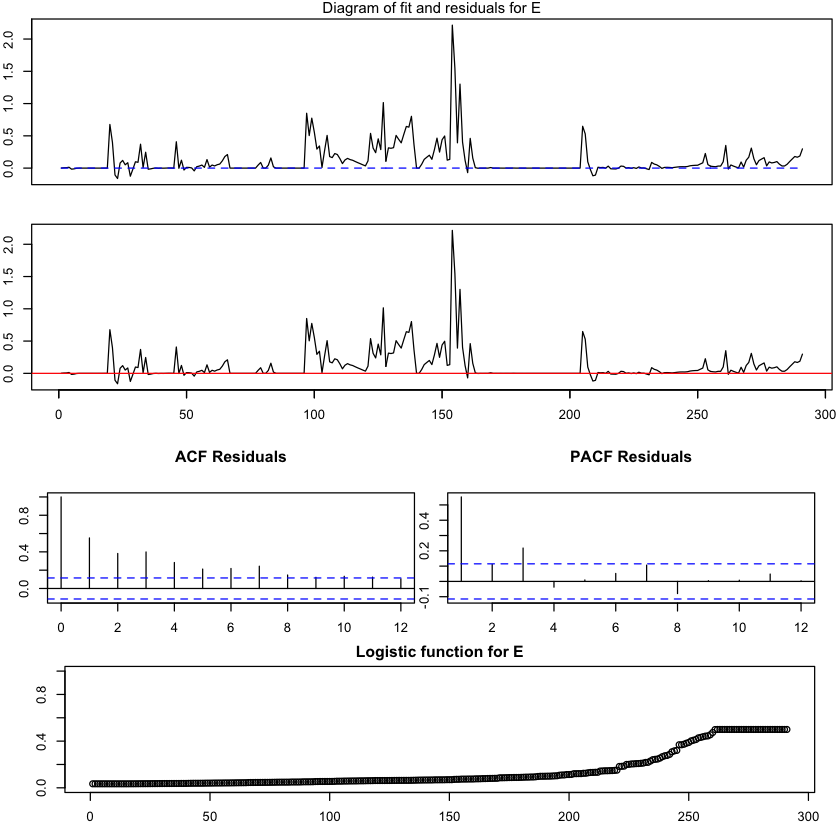

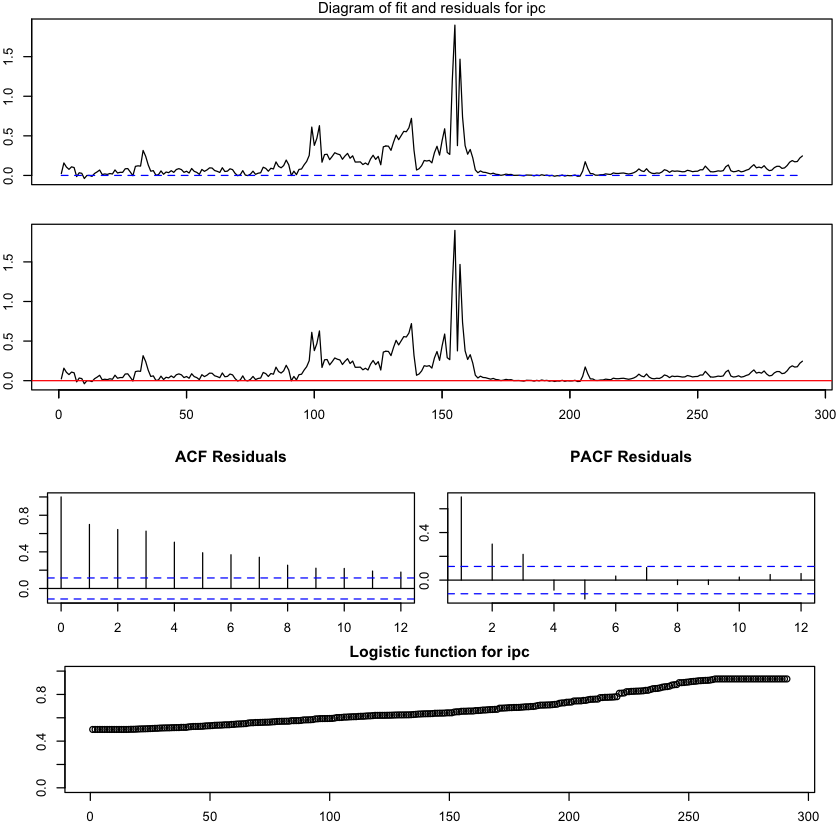

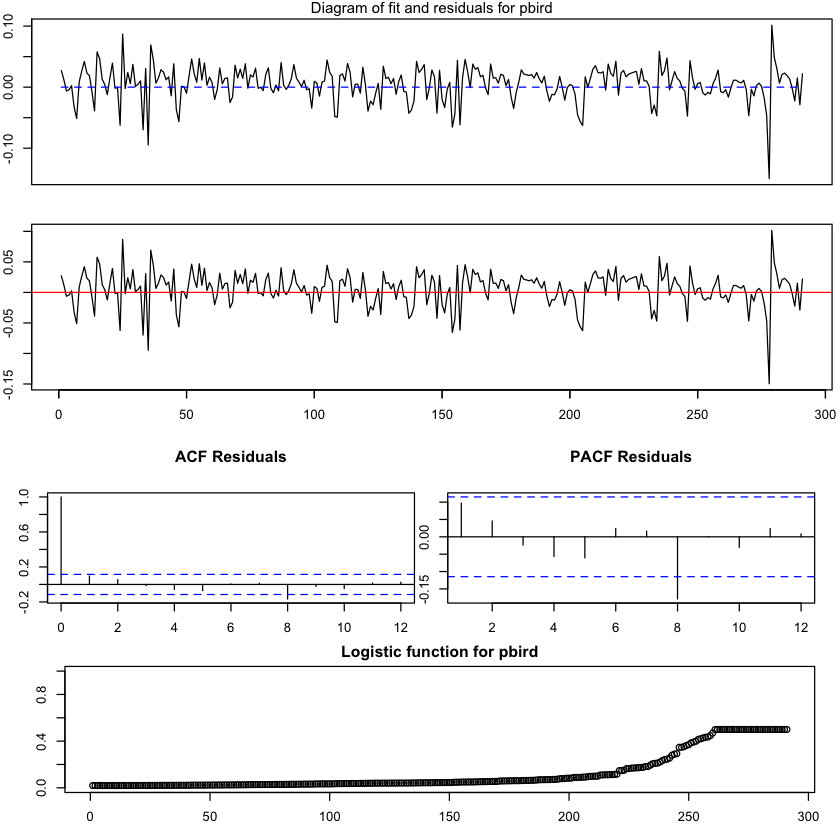

In [16]:
cat("\n>>> print(fit.VLSTAR)\n")
print(fit.VLSTAR)
 
cat("\n>>> summary(fit.VLSTAR)\n")
summary(fit.VLSTAR)
 
cat("\n>>> predict (1-step ahead)\n")
pred <- predict(fit.VLSTAR, st.num = 1, n.ahead = 1)
print(pred)
 
cat("\n>>> Log-likelihood (univariate)\n")
ll <- logLik(fit.VLSTAR, type = "Univariate")
print(ll)
 
cat("\n>>> Coefficients\n")
coefs <- coef(fit.VLSTAR)
print(coefs)

cat("\n>>> plot(fit.VLSTAR)\n")
plot(fit.VLSTAR)

## Resultados - acumulado

```txt
#    irf.VLSTAR() computes regime-specific IRFs for the VLSTAR model.
#    We then cumulate them across horizons to get the total accumulated
#    effect of a shock — particularly useful for ERPT analysis, e.g.
#    "what is the total pass-through from E to ipc over N quarters?"
#
#    Arguments:
#      impulse  : name of the shocking variable
#      response : name of the responding variable
#      n.ahead  : number of horizons to compute
#      ci       : confidence level for bootstrap bands (set to NULL to skip)
#      nboot    : number of bootstrap replications (only used if ci != NULL)
```

In [17]:
irf_impulse  <- "E"     # variable being shocked (must be in endog_vars)
irf_response <- "ipc"   # variable whose response we measure (must be in endog_vars)
irf_horizon  <- 12      # number of quarters ahead
 
# --- Helper: compute IRF for one set of VAR coefficient matrices -------------
# coef_list : list of p matrices (n x n), one per lag, Phi_1 ... Phi_p
# shock_idx : column index of the shocked variable (1-based)
# n_ahead   : number of horizons
# Returns a matrix (n_ahead+1) x n  of impulse responses (row 1 = impact period)
 
compute_irf <- function(coef_list, n_vars, shock_idx, n_ahead) {
  p       <- length(coef_list)
  horizon <- n_ahead + 1
  irf_mat <- matrix(0, nrow = horizon, ncol = n_vars)
 
  # Impact period: unit shock to variable shock_idx
  irf_mat[1, shock_idx] <- 1
 
  # Iterate VAR recursion: y_t = Phi_1 y_{t-1} + ... + Phi_p y_{t-p}
  for (h in 2:horizon) {
    for (lag in 1:min(p, h - 1)) {
      irf_mat[h, ] <- irf_mat[h, ] + irf_mat[h - lag, ] %*% t(coef_list[[lag]])
    }
  }
  irf_mat
}

In [18]:
# --- Inspect coef() structure first -----------------------------------------
all_coefs  <- coef(fit.VLSTAR)
cat("\n>>> coef() structure diagnostic:\n")
cat("Number of equations:", length(all_coefs), "\n")
cat("First equation column names:\n")
print(names(all_coefs[[1]]))
cat("First equation head:\n")
print(head(all_coefs[[1]]))
cat("\n")


>>> coef() structure diagnostic:
Number of equations: 0 
First equation column names:
NULL
First equation head:
NULL



In [19]:
# --- Extract coefficient matrices from the VLSTAR fit ---------------------

all_coefs  <- coef(fit.VLSTAR)
n_vars     <- ncol(y)
var_names  <- colnames(y)
p          <- regression_var_lag
 
# Build coefficient arrays: regime_coefs[[regime]][[lag]] is an (n x n) matrix
# Rows = responding equations, Cols = lagged variables
regime_coefs <- list()
 
for (regime in 0:1) {
  regime_coefs[[regime + 1]] <- vector("list", p)
  for (lag in 1:p) {
    mat <- matrix(0, nrow = n_vars, ncol = n_vars)
    for (eq in seq_len(n_vars)) {
      eq_coefs  <- all_coefs[[eq]]
      # Column names follow pattern "Phi0_lag1", "Phi1_lag1", etc.
      col_names <- paste0("Phi", regime, "_lag", lag)
      # If regime == 1, coefficients are *incremental*; add regime 0 base
      if (regime == 1) {
        base_cols  <- paste0("Phi0_lag", lag)
        base_vals  <- as.numeric(eq_coefs[, base_cols, drop = TRUE])
        incr_vals  <- as.numeric(eq_coefs[, col_names, drop = TRUE])
        mat[eq, ]  <- base_vals + incr_vals
      } else {
        mat[eq, ]  <- as.numeric(eq_coefs[, col_names, drop = TRUE])
      }
    }
    regime_coefs[[regime + 1]][[lag]] <- mat
  }
}
 

ERROR: Error in mat[eq, ] <- as.numeric(eq_coefs[, col_names, drop = TRUE]): replacement has length zero


#### Cumulate IRFs

In [ ]:
impulse_idx  <- which(var_names == irf_impulse)
response_idx <- which(var_names == irf_response)
 
if (length(impulse_idx) == 0)
  stop("irf_impulse variable '", irf_impulse, "' not found in endog_vars.")
if (length(response_idx) == 0)
  stop("irf_response variable '", irf_response, "' not found in endog_vars.")
 
regime_labels <- c("Regime 0 (low ipc)", "Regime 1 (high ipc)")
cirf_results  <- list()
 
cat("\n>>> Cumulative IRFs:", irf_impulse, "->", irf_response, "\n\n")
 
for (r in 1:2) {
  irf_mat  <- compute_irf(regime_coefs[[r]], n_vars, impulse_idx, irf_horizon)
  irf_vec  <- irf_mat[, response_idx]          # period-by-period IRF
  cirf_vec <- cumsum(irf_vec)                  # cumulative IRF
 
  cirf_results[[r]] <- list(irf = irf_vec, cirf = cirf_vec)
 
  df_out <- data.frame(
    horizon = 0:irf_horizon,
    IRF     = round(irf_vec,  6),
    CIRF    = round(cirf_vec, 6)
  )
  cat(regime_labels[r], "\n")
  print(df_out, row.names = FALSE)
  cat("\n")
}


>>> Cumulative IRFs: E -> ipc 



ERROR: Error in t.default(coef_list[[lag]]): argument is not a matrix


# Plot

In [ ]:
par(mfrow = c(2, 2), mar = c(4, 4, 3, 1))
horizons <- 0:irf_horizon
 
for (r in 1:2) {
  # Period-by-period IRF
  plot(horizons, cirf_results[[r]]$irf,
       type = "l", lwd = 2, col = "steelblue",
       xlab = "Horizon (quarters)", ylab = "Response",
       main = paste0("IRF: ", irf_impulse, " -> ", irf_response,
                     "\n", regime_labels[r]))
  abline(h = 0, lty = 2, col = "grey60")
 
  # Cumulative IRF
  plot(horizons, cirf_results[[r]]$cirf,
       type = "l", lwd = 2, col = "darkred",
       xlab = "Horizon (quarters)", ylab = "Cumulative response",
       main = paste0("CIRF: ", irf_impulse, " -> ", irf_response,
                     "\n", regime_labels[r]))
  abline(h = 0, lty = 2, col = "grey60")
}
 
par(mfrow = c(1, 1))
 

ERROR: Error in cirf_results[[r]]: subscript out of bounds
